# PIQE Step-by-Step in Google Colab

This notebook explains and implements the main workflow of the **Perception-based Image Quality Evaluator (PIQE)**, also referred to as **PIQUE** in the original paper.

PIQE is a **no-reference image quality assessment** method. This means that it estimates image quality using only the input image, without requiring a pristine reference image.

The method is based on local perceptual analysis. Instead of predicting quality from the whole image at once, PIQE analyzes the image block by block, detects spatially active regions, identifies possible local distortions, builds a distortion map, and then pools the local distortion scores into a final image quality score.

In this notebook you will:

1. Upload an image from your computer.
2. Convert it to grayscale/luminance.
3. Compute MSCN coefficients.
4. Divide the image into non-overlapping 16 × 16 blocks.
5. Identify uniform and spatially active blocks.
6. Apply the noticeable distortion criterion.
7. Apply the noise criterion.
8. Generate a block-level distortion map.
9. Compute the final PIQE score.
10. Visualize every important step.

> **Important:** This notebook computes a PIQE-like score following the algorithmic logic described in the PIQE/PIQUE paper. The output is shown both in the original range **0 to 1** and in a practical scaled range **0 to 100**.

In [1]:
# ============================================================
# 1. Install and import required libraries
# ============================================================

!pip -q install opencv-python-headless scipy pandas matplotlib pillow

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import convolve
from google.colab import files
from IPython.display import display

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

print("Libraries loaded successfully.")
print("OpenCV version:", cv2.__version__)

Libraries loaded successfully.
OpenCV version: 4.13.0


## 2. Upload an image from your computer

Run the next cell and select one image file from your PC.

Saving original.jpg to original.jpg
Uploaded image: original.jpg


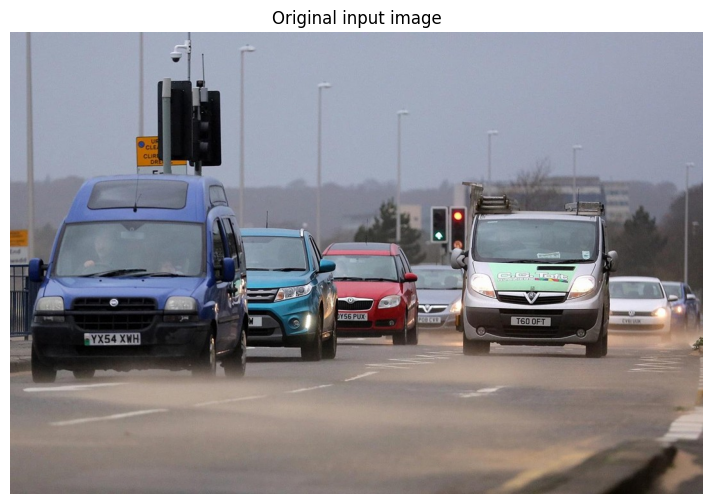

Image shape: (720, 1080, 3)


In [2]:
# ============================================================
# 2. Upload image from PC
# ============================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("The image could not be read. Please upload a valid image file.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(img_rgb)
plt.title("Original input image")
plt.axis("off")
plt.show()

print("Image shape:", img_rgb.shape)

## 3. Convert the image to grayscale/luminance

PIQE analyzes luminance information. Therefore, the input color image is converted into a grayscale representation.

This step makes the analysis focus on intensity variations, local contrast, edges, texture, blur, noise, and block-level degradations.

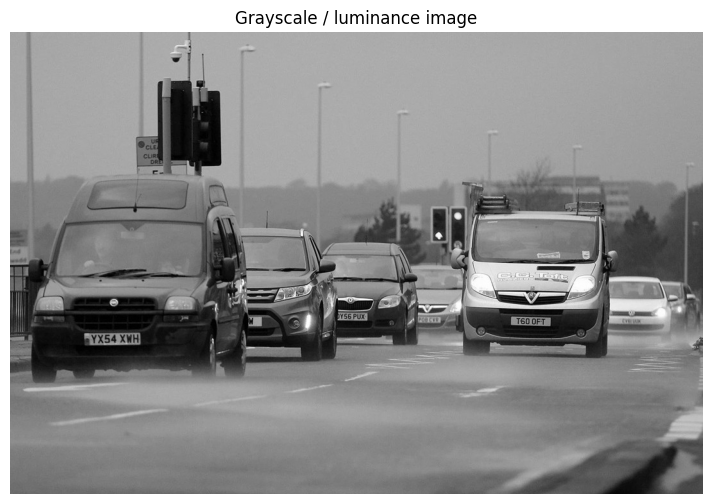

Grayscale image size: (720, 1080)


In [3]:
# ============================================================
# 3. Convert to grayscale/luminance
# ============================================================

gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(9, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale / luminance image")
plt.axis("off")
plt.show()

print("Grayscale image size:", gray.shape)

## 4. Compute MSCN coefficients

PIQE begins with local mean removal and divisive normalization. This produces **Mean Subtracted Contrast Normalized (MSCN)** coefficients:

\[
\hat{I}(i,j)=\frac{I(i,j)-\mu(i,j)}{\sigma(i,j)+C}
\]

where:

- \(I(i,j)\) is the luminance value at pixel location \((i,j)\).
- \(\mu(i,j)\) is the local mean.
- \(\sigma(i,j)\) is the local standard deviation.
- \(C\) is a small constant used to avoid numerical instability.

The MSCN map reduces local brightness and contrast effects, making local distortions easier to analyze.

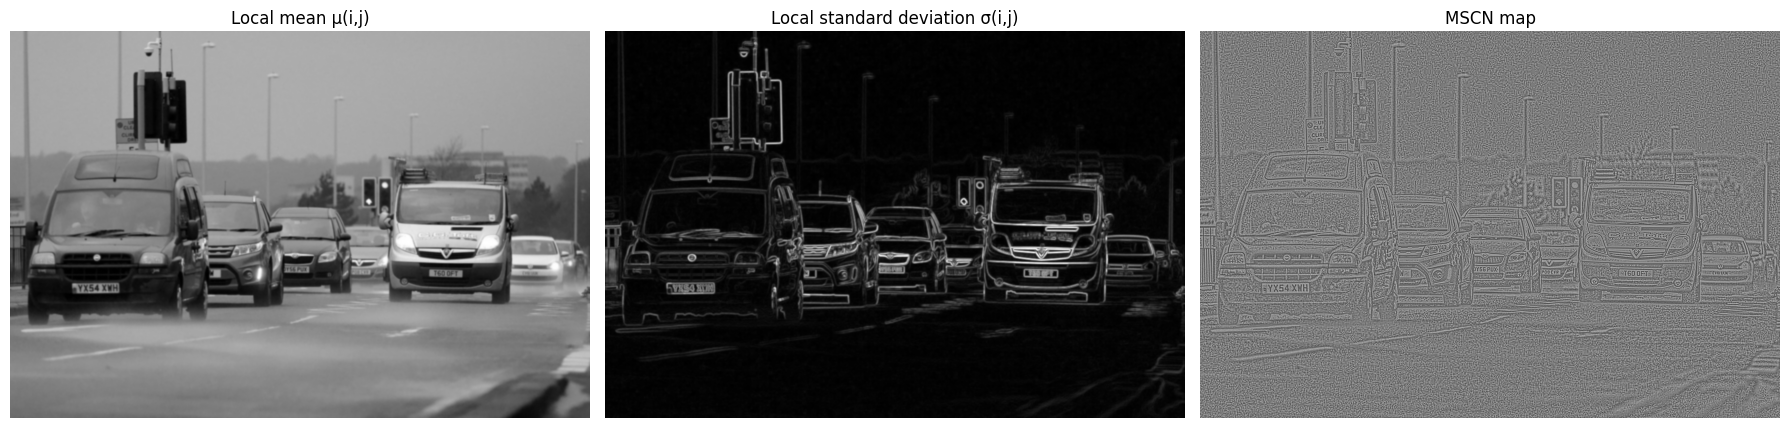

MSCN statistics:
Mean: -9.778530208219339e-05
Standard deviation: 0.4551830350042191
Minimum: -1.9870103323742883
Maximum: 2.105362683100672


In [4]:
# ============================================================
# 4. MSCN computation
# ============================================================

def gaussian_kernel_2d(size=7, sigma=7/6):
    # Creates a normalized 2D Gaussian kernel.
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

def compute_mscn_coefficients(image, C=1.0, kernel_size=7, sigma=7/6):
    # Computes MSCN coefficients:
    # I_hat(i,j) = [I(i,j) - mu(i,j)] / [sigma(i,j) + C]
    image = image.astype(np.float64)
    kernel = gaussian_kernel_2d(kernel_size, sigma)

    local_mean = convolve(image, kernel, mode="reflect")
    local_var = convolve(image**2, kernel, mode="reflect") - local_mean**2
    local_var = np.maximum(local_var, 0)
    local_std = np.sqrt(local_var)

    mscn = (image - local_mean) / (local_std + C)
    return mscn, local_mean, local_std

mscn, local_mean, local_std = compute_mscn_coefficients(gray)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(local_mean, cmap="gray")
axs[0].set_title("Local mean μ(i,j)")
axs[0].axis("off")

axs[1].imshow(local_std, cmap="gray")
axs[1].set_title("Local standard deviation σ(i,j)")
axs[1].axis("off")

axs[2].imshow(mscn, cmap="gray")
axs[2].set_title("MSCN map")
axs[2].axis("off")

plt.tight_layout()
plt.show()

print("MSCN statistics:")
print("Mean:", np.mean(mscn))
print("Standard deviation:", np.std(mscn))
print("Minimum:", np.min(mscn))
print("Maximum:", np.max(mscn))

## 5. Visualize the MSCN coefficient distribution

The histogram helps visualize how the normalized luminance coefficients are distributed.

In natural images, MSCN coefficients usually follow a regular statistical behavior. Distortions such as blur, noise, blocking artifacts, or compression can modify this behavior.

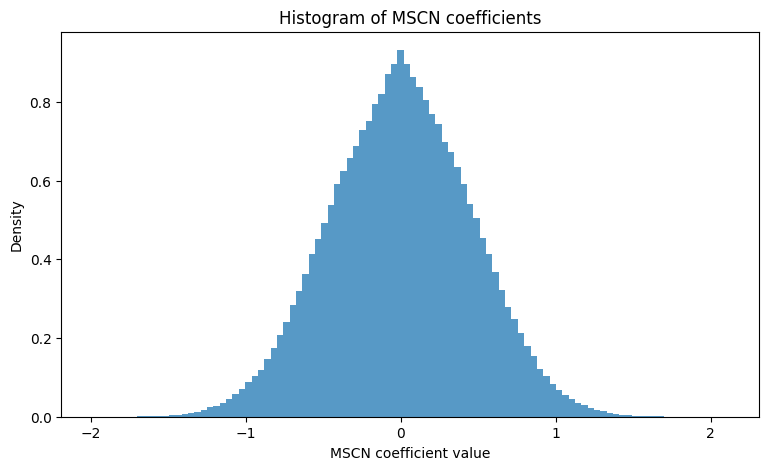

In [5]:
# ============================================================
# 5. MSCN histogram
# ============================================================

coeff = mscn.flatten()
coeff = coeff[np.isfinite(coeff)]
coeff_plot = coeff[(coeff > -5) & (coeff < 5)]

plt.figure(figsize=(9, 5))
plt.hist(coeff_plot, bins=100, density=True, alpha=0.75)
plt.title("Histogram of MSCN coefficients")
plt.xlabel("MSCN coefficient value")
plt.ylabel("Density")
plt.show()

## 6. Divide the image into non-overlapping 16 × 16 blocks

PIQE works at the local block level. The original paper uses blocks of size:

\[
n \times n = 16 \times 16
\]

Each block is later classified as either:

- **Uniform block (U)**: low spatial activity.
- **Spatially active block (SA)**: relevant local structure, texture, or detail.

Cropped image size: (720, 1072)
Block size: 16 x 16
Number of blocks: 3015


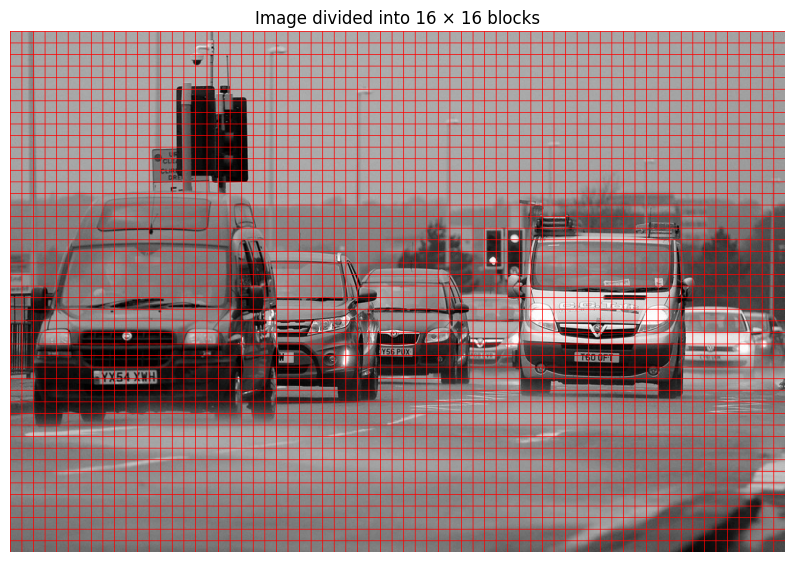

In [6]:
# ============================================================
# 6. Divide image into 16x16 blocks
# ============================================================

BLOCK_SIZE = 16

def crop_to_multiple(image, block_size):
    h, w = image.shape[:2]
    new_h = (h // block_size) * block_size
    new_w = (w // block_size) * block_size
    return image[:new_h, :new_w]

gray_cropped = crop_to_multiple(gray, BLOCK_SIZE)
mscn_cropped = crop_to_multiple(mscn, BLOCK_SIZE)

h, w = gray_cropped.shape
num_rows = h // BLOCK_SIZE
num_cols = w // BLOCK_SIZE
num_blocks = num_rows * num_cols

print("Cropped image size:", gray_cropped.shape)
print("Block size:", BLOCK_SIZE, "x", BLOCK_SIZE)
print("Number of blocks:", num_blocks)

# Draw grid over the grayscale image
grid_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for y in range(0, h + 1, BLOCK_SIZE):
    cv2.line(grid_img, (0, y), (w, y), (255, 0, 0), 1)

for x in range(0, w + 1, BLOCK_SIZE):
    cv2.line(grid_img, (x, 0), (x, h), (255, 0, 0), 1)

plt.figure(figsize=(10, 7))
plt.imshow(grid_img)
plt.title("Image divided into 16 × 16 blocks")
plt.axis("off")
plt.show()

## 7. Classify blocks as uniform or spatially active

The original PIQE method classifies each block according to the variance of its MSCN coefficients:

\[
B_k =
\begin{cases}
U, & \nu_k < T_U \\
SA, & \nu_k \geq T_U
\end{cases}
\]

where:

- \(B_k\) is the analyzed block.
- \(\nu_k\) is the variance of the MSCN coefficients in that block.
- \(U\) means uniform block.
- \(SA\) means spatially active block.
- \(T_U\) is the spatial activity threshold.

Only spatially active blocks are analyzed for distortion because they are more perceptually relevant.

Uniform blocks: 182
Spatially active blocks: 2833


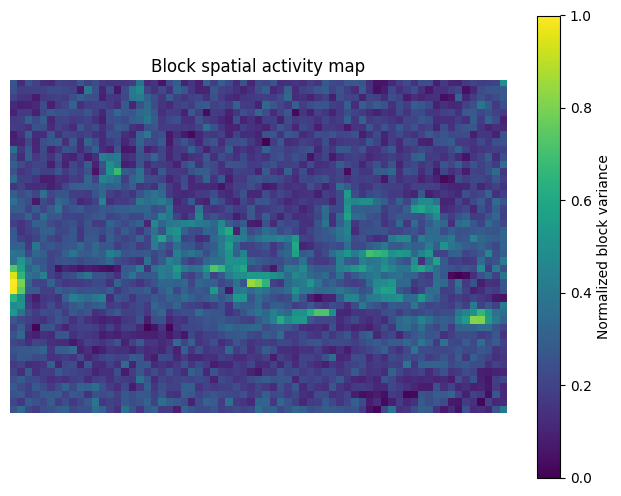

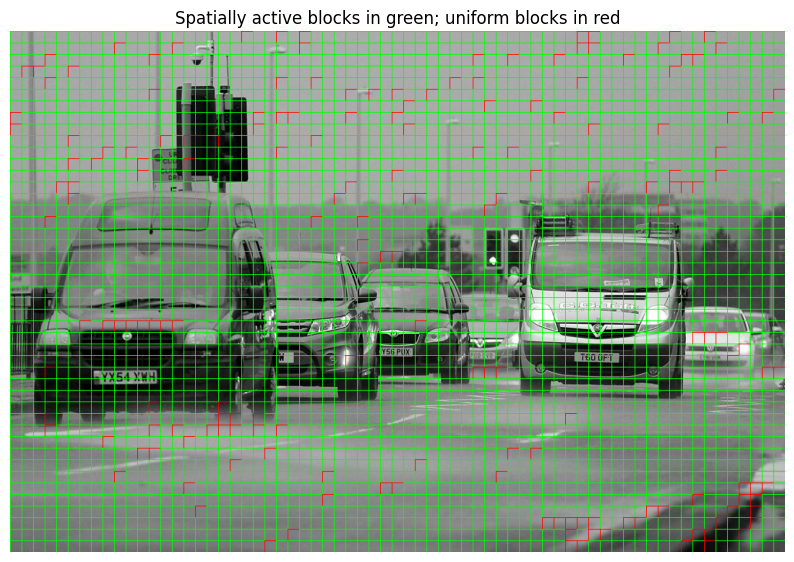

,Block index,Variance,Normalized variance,Spatially active
0,1,0.223403,0.258280,True
1,2,0.133709,0.119584,True
2,3,0.217522,0.249186,True
3,4,0.182892,0.195637,True
4,5,0.144600,0.136426,True
5,6,0.135030,0.121628,True
6,7,0.182513,0.195052,True
7,8,0.175354,0.183980,True
8,9,0.167724,0.172183,True
9,10,0.228629,0.266361,True


In [7]:
# ============================================================
# 7. Uniform vs spatially active blocks
# ============================================================

# Threshold used in the PIQE paper is conceptually 10%.
# Here, normalized block variance is used for visualization and scoring.
TU = 0.10

block_variances = []
block_positions = []

for r in range(num_rows):
    for c in range(num_cols):
        y0 = r * BLOCK_SIZE
        x0 = c * BLOCK_SIZE
        block = mscn_cropped[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE]
        var = np.var(block)
        block_variances.append(var)
        block_positions.append((x0, y0))

block_variances = np.array(block_variances)

# Normalize variance to [0, 1] for thresholding and visualization
var_min = block_variances.min()
var_max = block_variances.max()
block_variances_norm = (block_variances - var_min) / (var_max - var_min + 1e-12)

spatially_active = block_variances_norm >= TU

print("Uniform blocks:", np.sum(~spatially_active))
print("Spatially active blocks:", np.sum(spatially_active))

activity_map = np.zeros((num_rows, num_cols), dtype=np.float64)
for idx, value in enumerate(block_variances_norm):
    r = idx // num_cols
    c = idx % num_cols
    activity_map[r, c] = value

plt.figure(figsize=(8, 6))
plt.imshow(activity_map, cmap="viridis")
plt.colorbar(label="Normalized block variance")
plt.title("Block spatial activity map")
plt.axis("off")
plt.show()

# Visualization of selected SA blocks
sa_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for idx, (x0, y0) in enumerate(block_positions):
    color = (0, 255, 0) if spatially_active[idx] else (255, 0, 0)
    thickness = 1
    cv2.rectangle(sa_img, (x0, y0), (x0 + BLOCK_SIZE, y0 + BLOCK_SIZE), color, thickness)

plt.figure(figsize=(10, 7))
plt.imshow(sa_img)
plt.title("Spatially active blocks in green; uniform blocks in red")
plt.axis("off")
plt.show()

blocks_df = pd.DataFrame({
    "Block index": np.arange(1, num_blocks + 1),
    "Variance": block_variances,
    "Normalized variance": block_variances_norm,
    "Spatially active": spatially_active
})
display(blocks_df.head(20))

## 8. Noticeable distortion criterion

PIQE checks whether a spatially active block has local edge segments with low spatial activity.

For each 16 × 16 block, the four edges are analyzed. Each edge is divided into 11 overlapping segments of 6 pixels.

A block is considered affected by a noticeable distortion if at least one edge segment has a standard deviation below a threshold:

\[
\sigma_{pq} < T_{STD}
\]

This criterion is useful for detecting blur, blockiness, and other local structural degradations.

Blocks with noticeable distortion: 1149


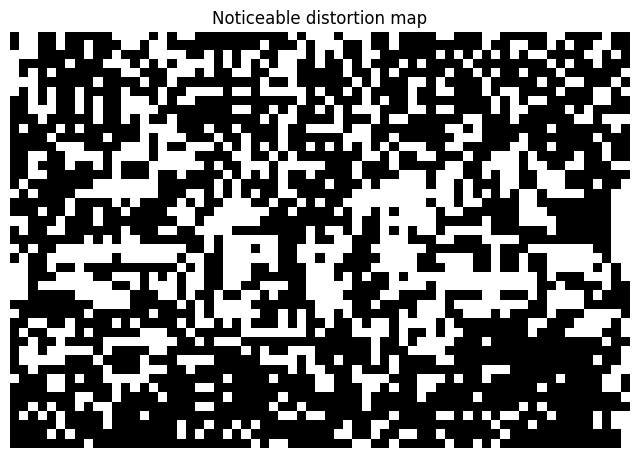

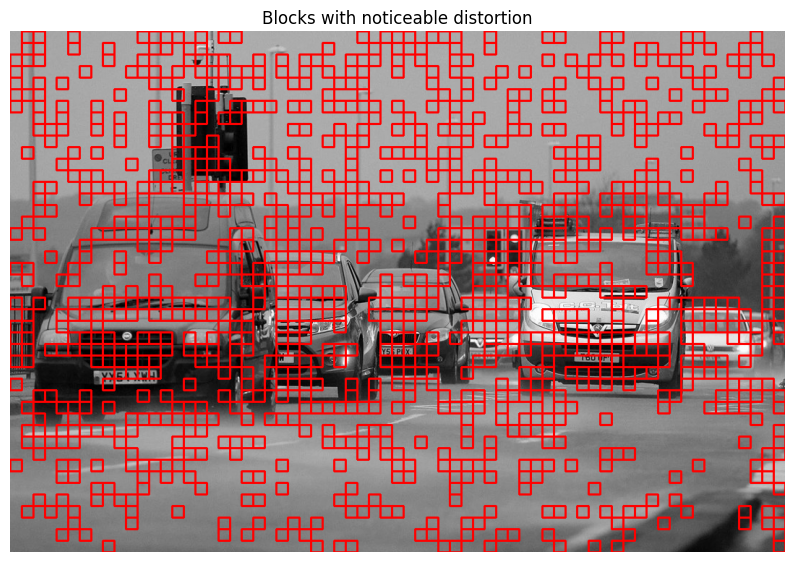

In [8]:
# ============================================================
# 8. Noticeable distortion criterion
# ============================================================

TSTD = 0.10

def edge_segments_low_activity(block, threshold=TSTD):
    # The block is 16x16.
    # Edges: top, bottom, left, right.
    edges = [
        block[0, :],      # top
        block[-1, :],     # bottom
        block[:, 0],      # left
        block[:, -1]      # right
    ]

    low_activity_segments = 0

    for edge in edges:
        # 16-pixel edge -> 11 segments of length 6
        for q in range(0, len(edge) - 6 + 1):
            segment = edge[q:q+6]
            if np.std(segment) < threshold:
                low_activity_segments += 1

    noticeable_distortion = low_activity_segments > 0
    return noticeable_distortion, low_activity_segments

noticeable_flags = []
low_segment_counts = []

for idx, (x0, y0) in enumerate(block_positions):
    block = mscn_cropped[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE]

    if spatially_active[idx]:
        flag, count = edge_segments_low_activity(block, threshold=TSTD)
    else:
        flag, count = False, 0

    noticeable_flags.append(flag)
    low_segment_counts.append(count)

noticeable_flags = np.array(noticeable_flags)
low_segment_counts = np.array(low_segment_counts)

print("Blocks with noticeable distortion:", np.sum(noticeable_flags))

noticeable_map = noticeable_flags.reshape(num_rows, num_cols)

plt.figure(figsize=(8, 6))
plt.imshow(noticeable_map, cmap="gray")
plt.title("Noticeable distortion map")
plt.axis("off")
plt.show()

# Overlay on image
noticeable_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for idx, (x0, y0) in enumerate(block_positions):
    if noticeable_flags[idx]:
        cv2.rectangle(noticeable_img, (x0, y0), (x0 + BLOCK_SIZE, y0 + BLOCK_SIZE), (255, 0, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(noticeable_img)
plt.title("Blocks with noticeable distortion")
plt.axis("off")
plt.show()

## 9. Noise criterion

PIQE also evaluates whether a spatially active block is affected by noise.

The method uses a **center-surround criterion** inspired by human visual perception.

For each block:

- The central region is compared with the surrounding region.
- A parameter \(\beta\) is computed.
- A block is considered noisy if:

\[
\sigma_{blk} > 2\beta
\]

where \(\sigma_{blk}\) is the standard deviation of the block.

Blocks classified as noisy: 96


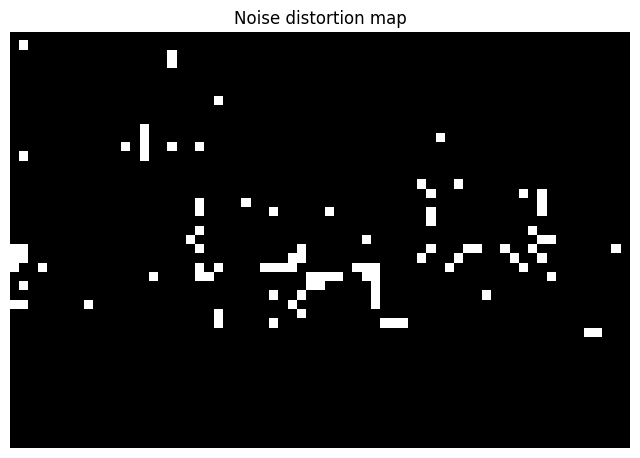

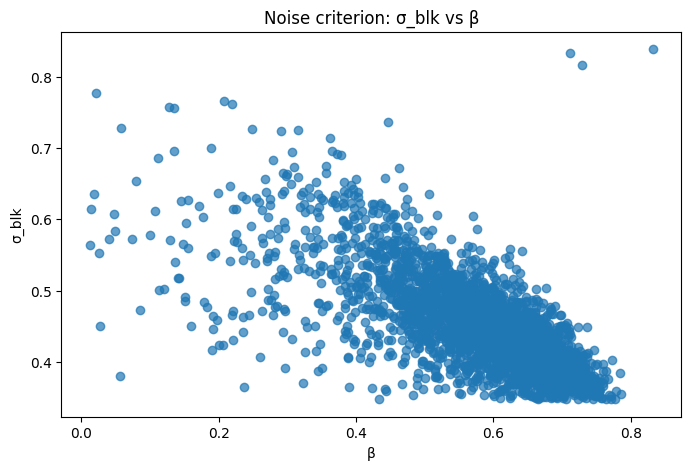

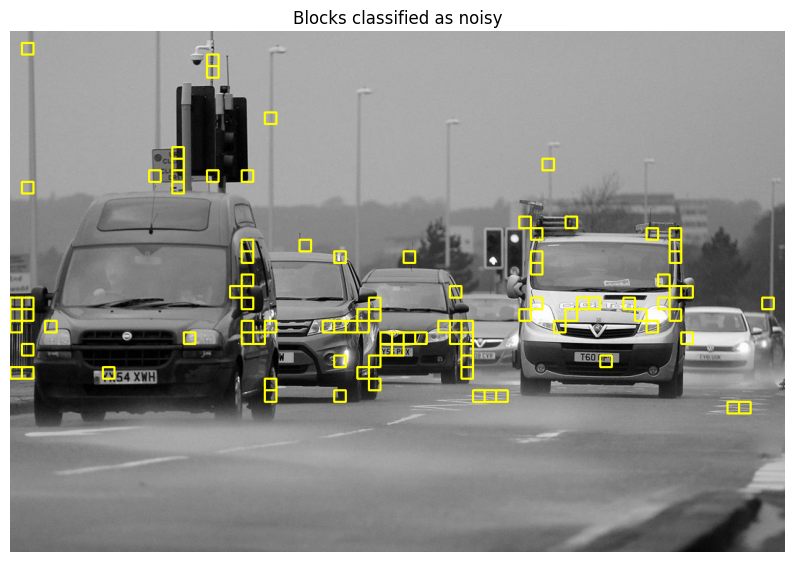

In [9]:
# ============================================================
# 9. Noise criterion
# ============================================================

def noise_criterion(block):
    # block is 16x16 MSCN coefficients
    # Center region: center two columns
    center = block[:, 7:9]

    # Surround region: all columns except center two
    surround = np.concatenate([block[:, :7], block[:, 9:]], axis=1)

    sigma_cen = np.std(center)
    sigma_sur = np.std(surround)
    sigma_blk = np.std(block)

    ratio = sigma_cen / (sigma_sur + 1e-12)

    beta = abs(ratio - sigma_blk) / max(ratio, sigma_blk, 1e-12)

    noisy = sigma_blk > 2 * beta

    return noisy, sigma_cen, sigma_sur, sigma_blk, beta

noise_flags = []
beta_values = []
sigma_blk_values = []

for idx, (x0, y0) in enumerate(block_positions):
    block = mscn_cropped[y0:y0+BLOCK_SIZE, x0:x0+BLOCK_SIZE]

    if spatially_active[idx]:
        noisy, sigma_cen, sigma_sur, sigma_blk, beta = noise_criterion(block)
    else:
        noisy, sigma_blk, beta = False, 0, 0

    noise_flags.append(noisy)
    sigma_blk_values.append(sigma_blk)
    beta_values.append(beta)

noise_flags = np.array(noise_flags)
sigma_blk_values = np.array(sigma_blk_values)
beta_values = np.array(beta_values)

print("Blocks classified as noisy:", np.sum(noise_flags))

noise_map = noise_flags.reshape(num_rows, num_cols)

plt.figure(figsize=(8, 6))
plt.imshow(noise_map, cmap="gray")
plt.title("Noise distortion map")
plt.axis("off")
plt.show()

# Scatter plot sigma_blk vs beta
plt.figure(figsize=(8, 5))
plt.scatter(beta_values[spatially_active], sigma_blk_values[spatially_active], alpha=0.7)
plt.xlabel("β")
plt.ylabel("σ_blk")
plt.title("Noise criterion: σ_blk vs β")
plt.show()

# Overlay noisy blocks
noise_img = cv2.cvtColor(gray_cropped.astype(np.uint8), cv2.COLOR_GRAY2RGB)

for idx, (x0, y0) in enumerate(block_positions):
    if noise_flags[idx]:
        cv2.rectangle(noise_img, (x0, y0), (x0 + BLOCK_SIZE, y0 + BLOCK_SIZE), (255, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(noise_img)
plt.title("Blocks classified as noisy")
plt.axis("off")
plt.show()

## 10. Assign local distortion scores

After identifying noticeable distortion and noise, PIQE assigns a local distortion score \(Ds_k\) to each spatially active block:

\[
Ds_k =
\begin{cases}
1, & \text{if both noticeable distortion and noise are detected} \\
\nu_{blk}, & \text{if noise is detected} \\
1-\nu_{blk}, & \text{if noticeable distortion is detected}
\end{cases}
\]

where \(\nu_{blk}\) is the normalized block variance.

Uniform blocks are not used in the final score because they are less perceptually informative.

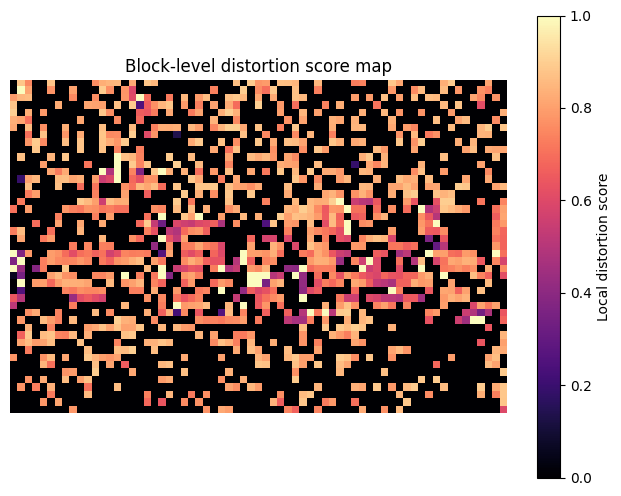

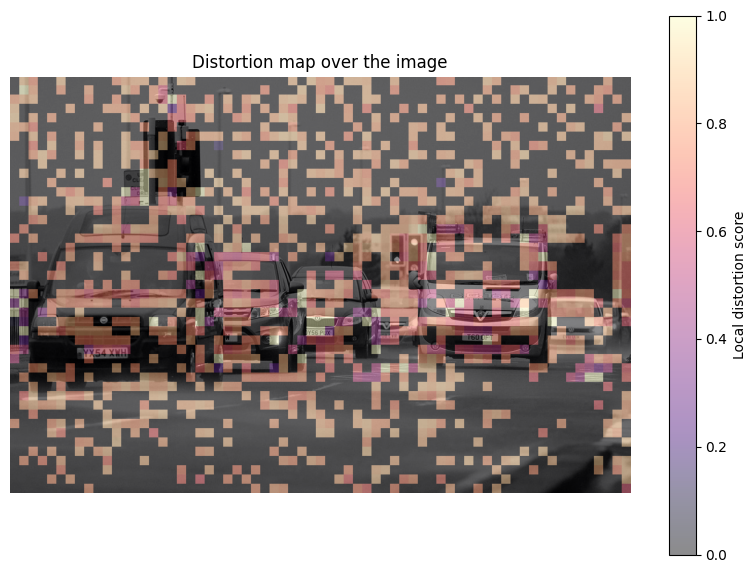

,Block index,Spatially active,Noticeable distortion,Noise,Normalized variance,Distortion score
0,1,True,False,False,0.258280,0.000000
1,2,True,True,False,0.119584,0.880416
2,3,True,True,False,0.249186,0.750814
3,4,True,False,False,0.195637,0.000000
4,5,True,False,False,0.136426,0.000000
5,6,True,True,False,0.121628,0.878372
6,7,True,False,False,0.195052,0.000000
7,8,True,False,False,0.183980,0.000000
8,9,True,False,False,0.172183,0.000000
9,10,True,False,False,0.266361,0.000000


In [10]:
# ============================================================
# 10. Local distortion score assignment
# ============================================================

distortion_scores = np.zeros(num_blocks, dtype=np.float64)

for idx in range(num_blocks):
    if not spatially_active[idx]:
        distortion_scores[idx] = 0
        continue

    nu_blk = block_variances_norm[idx]
    noticeable = noticeable_flags[idx]
    noisy = noise_flags[idx]

    if noticeable and noisy:
        distortion_scores[idx] = 1.0
    elif noisy:
        distortion_scores[idx] = nu_blk
    elif noticeable:
        distortion_scores[idx] = 1.0 - nu_blk
    else:
        distortion_scores[idx] = 0.0

distortion_map = distortion_scores.reshape(num_rows, num_cols)

plt.figure(figsize=(8, 6))
plt.imshow(distortion_map, cmap="magma", vmin=0, vmax=1)
plt.colorbar(label="Local distortion score")
plt.title("Block-level distortion score map")
plt.axis("off")
plt.show()

# Upscale distortion map to image size for visualization
distortion_map_up = cv2.resize(distortion_map, (w, h), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(10, 7))
plt.imshow(gray_cropped, cmap="gray")
plt.imshow(distortion_map_up, cmap="magma", alpha=0.45, vmin=0, vmax=1)
plt.colorbar(label="Local distortion score")
plt.title("Distortion map over the image")
plt.axis("off")
plt.show()

distortion_df = pd.DataFrame({
    "Block index": np.arange(1, num_blocks + 1),
    "Spatially active": spatially_active,
    "Noticeable distortion": noticeable_flags,
    "Noise": noise_flags,
    "Normalized variance": block_variances_norm,
    "Distortion score": distortion_scores
})

display(distortion_df.head(30))

## 11. Compute the final PIQE score

The final PIQE score is computed by pooling the distortion scores of spatially active blocks:

\[
PIQE =
\frac{
\sum_{k=1}^{N_{SA}} Ds_k + C_1
}{
N_{SA}+C_1
}
\]

where:

- \(Ds_k\) is the distortion score of the \(k\)-th spatially active block.
- \(N_{SA}\) is the number of spatially active blocks.
- \(C_1\) avoids numerical instability when the denominator is close to zero.

The original score is in the range 0 to 1:

- Values near 0 indicate better quality.
- Values near 1 indicate poorer quality.

For practical visualization, the score is also scaled to 0 to 100.

In [11]:
# ============================================================
# 11. Final PIQE score
# ============================================================

C1 = 1.0

NSA = int(np.sum(spatially_active))
sum_scores = np.sum(distortion_scores[spatially_active])

piqe_raw = (sum_scores + C1) / (NSA + C1)
piqe_100 = piqe_raw * 100

print("Number of spatially active blocks (NSA):", NSA)
print("Sum of distortion scores:", sum_scores)
print("Final PIQE score [0, 1]:", piqe_raw)
print("Final PIQE score [0, 100]:", piqe_100)

if piqe_raw < 0.3:
    interpretation = "Good perceptual quality"
elif piqe_raw < 0.5:
    interpretation = "Average perceptual quality"
else:
    interpretation = "Poor perceptual quality"

print("Interpretation:", interpretation)

Number of spatially active blocks (NSA): 2833
Sum of distortion scores: 919.1320239644513
Final PIQE score [0, 1]: 0.3246760846734126
Final PIQE score [0, 100]: 32.46760846734126
Interpretation: Average perceptual quality


## 12. Visual interpretation of the final PIQE score

The PIQE score can be interpreted approximately as follows:

| PIQE score | Interpretation |
|---|---|
| 0.0 to 0.3 | Good quality |
| 0.3 to 0.5 | Average quality |
| 0.5 to 1.0 | Poor quality |

When scaled to 0 to 100, lower values indicate better image quality and higher values indicate stronger visual degradation.

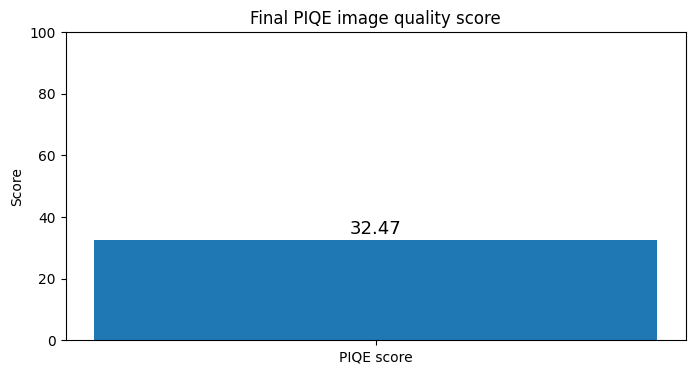

,Metric,Value
0,Total blocks,3015
1,Spatially active blocks,2833
2,Noticeable distortion blocks,1149
3,Noisy blocks,96
4,"PIQE score [0,1]",0.3247
5,"PIQE score [0,100]",32.47
6,Interpretation,Average perceptual quality


In [12]:
# ============================================================
# 12. Plot final PIQE score
# ============================================================

plt.figure(figsize=(8, 4))
plt.bar(["PIQE score"], [piqe_100])
plt.ylim(0, 100)
plt.ylabel("Score")
plt.title("Final PIQE image quality score")

plt.text(0, piqe_100 + 2, f"{piqe_100:.2f}", ha="center", fontsize=13)
plt.show()

# Summary table
summary_df = pd.DataFrame({
    "Metric": [
        "Total blocks",
        "Spatially active blocks",
        "Noticeable distortion blocks",
        "Noisy blocks",
        "PIQE score [0,1]",
        "PIQE score [0,100]",
        "Interpretation"
    ],
    "Value": [
        num_blocks,
        NSA,
        int(np.sum(noticeable_flags)),
        int(np.sum(noise_flags)),
        round(float(piqe_raw), 4),
        round(float(piqe_100), 2),
        interpretation
    ]
})

display(summary_df)

## 13. Complete PIQE workflow summary

The complete PIQE workflow can be summarized as:

\[
Image \rightarrow Grayscale \rightarrow MSCN \rightarrow 16 \times 16 Blocks \rightarrow Spatial Activity \rightarrow Distortion Detection \rightarrow Distortion Map \rightarrow PIQE Score
\]

In simple terms:

1. The image is converted to grayscale.
2. MSCN coefficients are computed.
3. The image is divided into 16 × 16 blocks.
4. Blocks are classified as uniform or spatially active.
5. Spatially active blocks are analyzed for noticeable distortion and noise.
6. Each distorted block receives a local distortion score.
7. The local scores are pooled into the final PIQE score.
8. A lower score indicates better perceptual image quality.